--- 步驟 1: 下載並載入資料集 ---
網址連線失敗，嘗試下一個... (錯誤: HTTP Error 404: Not Found)
成功從網址載入資料！來源：https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

--- 步驟 2: 特徵與目標變數設定 ---

--- 步驟 3: 訓練多元線性回歸模型 ---
【訓練集 (Train Set)】
  - RMSE : 6105.5452
  - R²   : 0.7417  (74.17%)
---------------------------------------------
【測試集 (Test Set)】
  - RMSE : 5796.2847
  - R²   : 0.7836  (78.36%)
提示：訓練集與測試集的 R² 相近（差距 -0.0419），模型泛化能力良好！


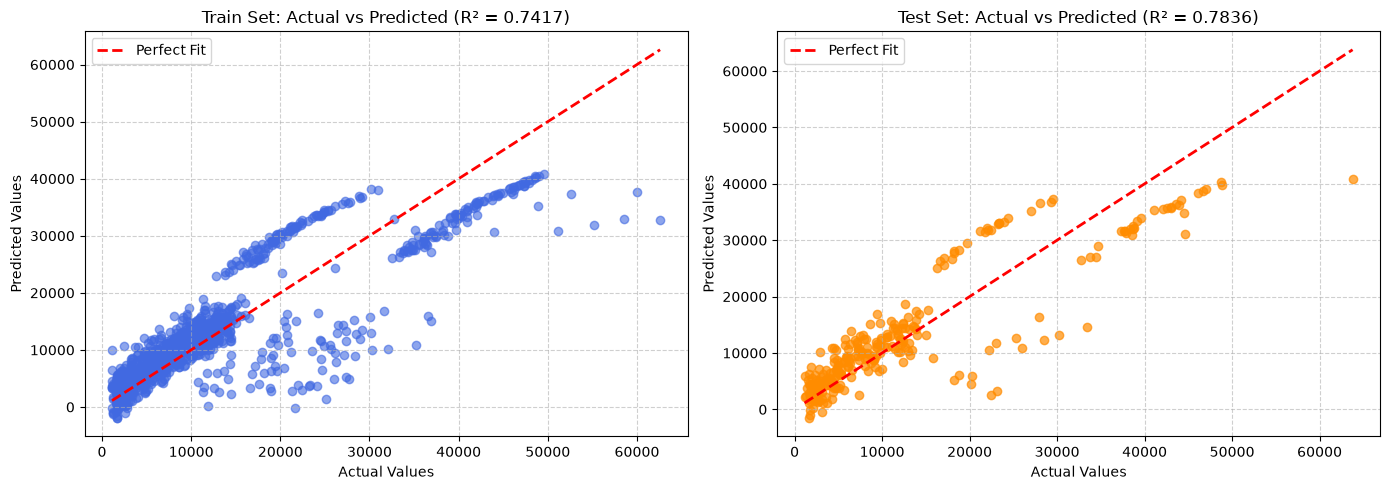

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- 步驟 1: 下載並載入資料集 ---")

urls = [
    "https://raw.githubusercontent.com/drshahizan/dataset/main/bodyfat.csv",
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv",
]

df = None
for url in urls:
    try:
        df = pd.read_csv(url)
        print(f"成功從網址載入資料！來源：{url}")
        break
    except Exception as e:
        print(f"網址連線失敗，嘗試下一個... (錯誤: {e})")

if df is None:
    raise ValueError(
        "無法載入資料，請檢查網路連線或是否能存取 GitHub 網址。"
    )

print("\n--- 步驟 2: 特徵與目標變數設定 ---")
if "BodyFat" in df.columns:
    Y = df["BodyFat"]
    X = df.drop(columns=["BodyFat", "Density"], errors="ignore")
elif "charges" in df.columns:
    df = pd.get_dummies(df, drop_first=True)
    Y = df["charges"]
    X = df.drop(columns=["charges"])

# 切分訓練集 (80%) 與測試集 (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# 特徵標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- 步驟 3: 訓練多元線性回歸模型 ---")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 1. 訓練集預測與評估
y_train_pred = model.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# 2. 測試集預測與評估
y_test_pred = model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# 輸出結果比對
print("=" * 45)
print(f"【訓練集 (Train Set)】")
print(f"  - RMSE : {train_rmse:.4f}")
print(f"  - R²   : {train_r2:.4f}  ({train_r2*100:.2f}%)")
print("-" * 45)
print(f"【測試集 (Test Set)】")
print(f"  - RMSE : {test_rmse:.4f}")
print(f"  - R²   : {test_r2:.4f}  ({test_r2*100:.2f}%)")
print("=" * 45)

# 過擬合（Overfitting）判斷建議
r2_diff = train_r2 - test_r2
if r2_diff > 0.15:
    print(
        f"提示：訓練集 R² 比測試集高出 {r2_diff:.4f}，模型可能存在過擬合 (Overfitting) 現象，建議嘗試 Ridge 或 Lasso 正則化。"
    )
else:
    print(
        f"提示：訓練集與測試集的 R² 相近（差距 {r2_diff:.4f}），模型泛化能力良好！"
    )

# ----------------------------------------------------
# 繪圖：同時比較訓練集與測試集的擬合情況
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖 1: 訓練集 實際值 vs 預測值
axes[0].scatter(y_train, y_train_pred, alpha=0.6, color="royalblue")
axes[0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    "r--",
    lw=2,
    label="Perfect Fit",
)
axes[0].set_title(
    f"Train Set: Actual vs Predicted (R² = {train_r2:.4f})", fontsize=12
)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# 圖 2: 測試集 實際值 vs 預測值
axes[1].scatter(y_test, y_test_pred, alpha=0.7, color="darkorange")
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Fit",
)
axes[1].set_title(
    f"Test Set: Actual vs Predicted (R² = {test_r2:.4f})", fontsize=12
)
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend)%

plt.tight_layout()
plt.show()